# 🗺️ GeoPandas — Mapas Estáticos: Análisis Económico del Perú
**Curso:** Scientific Computing | Economía Aplicada  
**Tema:** Visualización geoespacial con datos reales del Perú  
**Datasets:** Analfabetismo · Siembra de Coca · Presupuesto Carreteras · Internet · Delincuencia · Robos de Vehículos

---
> 📌 **Nota:** Cada bloque de código corresponde a un paso explicado en la diapositiva teórica. Los `# comentarios` indican dónde se aplica cada concepto del PPT.


## 0️⃣  Instalación y Configuración

In [14]:
# ─── Instalar librerías (ejecutar solo la primera vez) ───────────────────────
!pip install geopandas
!pip install matplotlib
!pip install chardet
!pip install openpyxl
!pip install requests


   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/22.9 MB 6.2 MB/s eta 0:00:04
   --- ------------------------------------ 2.1/22.9 MB 5.3 MB/s eta 0:00:04
   ----- ---------------------------------- 3.4/22.9 MB 5.8 MB/s eta 0:00:04
   -------- ------------------------------- 5.0/22.9 MB 6.3 MB/s eta 0:00:03
   ----------- ---------------------------- 6.8/22.9 MB 6.9 MB/s eta 0:00:03
   ---------------- ----------------------- 9.2/22.9 MB 7.6 MB/s eta 0:00:02
   ------------------- -------------------- 11.0/22.9 MB 7.8 MB/s eta 0:00:02
   ----------------------- ---------------- 13.4/22.9 MB 8.3 MB/s eta 0:00:02
   --------------------------- ------------ 15.7/22.9 MB 8.7 MB/s eta 0:00:01
   -------------------------------- ------- 18.4/22.9 MB 9.1 MB/s eta 0:00:01
   ------------------------------------ --- 21.0/22.9 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 9.7 MB/s  0:00:02
   

In [15]:
# ─── Importar todas las librerías del curso ──────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import chardet
import requests
import warnings
warnings.filterwarnings('ignore')

import geopandas as gpd
from geopandas import GeoSeries
from shapely.geometry import Point, LineString

print("✅ Librerías cargadas correctamente")
print(f"   geopandas version: {gpd.__version__}")


✅ Librerías cargadas correctamente
   geopandas version: 1.1.3


In [16]:
from IPython.display import display, HTML
display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))


## 1️⃣  Obtener Geometría del Perú  
### Fuentes de geometría (PPT → Slide 7)

| Fuente | URL | Nivel |
|--------|-----|-------|
| **GeoBoundaries** (académico) | geoboundaries.org | ✅ Departamental |
| **HDX / OCHA** (ONU) | data.humdata.org | ✅ Multi-nivel |
| **IDE - INEI** (oficial Perú) | ide.inei.gob.pe | ✅ Oficial |
| **GeoGPS Perú** | geogpsperu.com | ✅ Procesado |

> 📌 **PPT Slide 3 & 7:** Un Shapefile/GeoJSON es una tabla con UBIGEO + columna `geometry`. Aquí obtenemos esa tabla desde una fuente confiable.


In [17]:
# ─── PASO 1: Descargar geometría departamental del Perú ──────────────────────
# Fuente: GeoBoundaries (College of William & Mary) — estándar académico internacional
# URL API: https://www.geoboundaries.org/api/current/gbOpen/PER/ADM1/

print("📥 Descargando geometría departamental del Perú desde GeoBoundaries...")

try:
    api_url = "https://www.geoboundaries.org/api/current/gbOpen/PER/ADM1/"
    response = requests.get(api_url, timeout=15)
    meta = response.json()
    geojson_url = meta['gjDownloadURL']
    
    dpto_geo = gpd.read_file(geojson_url)
    print(f"✅ Descargado correctamente: {len(dpto_geo)} departamentos")
    
except Exception as e:
    print(f"⚠️  Error con GeoBoundaries: {e}")
    print("🔄 Usando fuente alternativa (HDX)...")
    
    # Alternativa: HDX (Humanitarian Data Exchange - ONU)
    hdx_url = ("https://data.humdata.org/dataset/cod-ab-per/resource/"
                "b7f9c85a-1cdf-4a42-b04b-a7cdab5f00e6/download/"
                "per_admbndas_admall_ign_20200714_shp.zip")
    dpto_geo = gpd.read_file(f"zip+{hdx_url}!per_admbnda_adm1_ign_20200714.shp")
    print(f"✅ Alternativa cargada: {len(dpto_geo)} departamentos")


📥 Descargando geometría departamental del Perú desde GeoBoundaries...
✅ Descargado correctamente: 26 departamentos


In [18]:
# ─── PASO 2: Explorar el GeoDataFrame (PPT Slide 3 — Shapefile) ─────────────
# Esta tabla ES el shapefile: tiene columnas normales + la columna especial "geometry"

print("─── Primeras filas del GeoDataFrame ────")
display(dpto_geo.head())

print(f"\n─── Forma de la tabla ──────────────────")
print(f"  Filas: {dpto_geo.shape[0]}  |  Columnas: {dpto_geo.shape[1]}")

print(f"\n─── Nombres de columnas ────────────────")
print(list(dpto_geo.columns))


─── Primeras filas del GeoDataFrame ────


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Puno,PE-PUN,1875124B3772980127380,PER,ADM1,"POLYGON ((-69.57987 -17.30313, -69.60561 -17.2..."
1,Tumbes,PE-TUM,1875124B82769317880582,PER,ADM1,"POLYGON ((-80.49374 -4.07288, -80.49807 -4.058..."
2,Piura,PE-PIU,1875124B64829338827261,PER,ADM1,"POLYGON ((-81.05565 -4.07968, -81.05807 -4.083..."
3,Lambayeque,PE-LAM,1875124B61751373376494,PER,ADM1,"POLYGON ((-80.63906 -6.35623, -80.62161 -6.364..."
4,Cajamarca,PE-CAJ,1875124B51528250409360,PER,ADM1,"POLYGON ((-79.41533 -5.95522, -79.41209 -5.960..."



─── Forma de la tabla ──────────────────
  Filas: 26  |  Columnas: 6

─── Nombres de columnas ────────────────
['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


In [19]:
# ─── PASO 3: Ver la columna geometry (PPT Slide 3) ───────────────────────────
# La columna geometry almacena colecciones de puntos que forman polígonos

print("Tipo de dato de geometry:", type(dpto_geo.geometry[0]))
print("\nEjemplo — geometría del primer departamento:")
print(dpto_geo['geometry'].iloc[0])


Tipo de dato de geometry: <class 'shapely.geometry.polygon.Polygon'>

Ejemplo — geometría del primer departamento:
POLYGON ((-69.57987444052179 -17.30313034612385, -69.60560771846667 -17.28828422423254, -69.59842564193434 -17.259555918103274, -69.58508749980291 -17.239035699439512, -69.55020312807449 -17.19902127304516, -69.52865689847738 -17.181579087180864, -69.49992859234817 -17.16105886851716, -69.46812225341932 -17.150798759185307, -69.42605580515857 -17.125148485855505, -69.38604137876428 -17.102576245325395, -69.37372924756596 -17.084108048528037, -69.35936509450136 -17.030755480002142, -69.34089689770394 -17.010235261338323, -69.32550673370605 -16.99074105360785, -69.29902282649317 -16.96605266552791, -69.25734113233239 -16.909942692619154, -69.22569639012539 -16.871231300109912, -69.19286404026343 -16.833145774270008, -69.17710451232966 -16.80884983537203, -69.15806174940963 -16.78127066148795, -69.1429588684731 -16.749094958623118, -69.11143981260557 -16.733992077686594, -69.

In [20]:
# ─── PASO 4: Seleccionar columnas relevantes ─────────────────────────────────
# Nos quedamos con: nombre del departamento + geometry

# Identificar la columna con el nombre del departamento
print("Columnas disponibles:", list(dpto_geo.columns))

# En GeoBoundaries la columna es 'shapeName'
col_nombre = 'shapeName'   # ← ajustar si usa otra fuente

dpto = dpto_geo[[col_nombre, 'geometry']].copy()
dpto = dpto.rename(columns={col_nombre: 'Departamento_geo'})

print("\nNombres de departamentos en el GeoJSON:")
for nombre in sorted(dpto['Departamento_geo'].tolist()):
    print(f"  · {nombre}")


Columnas disponibles: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']

Nombres de departamentos en el GeoJSON:
  · Amazonas
  · Ancash
  · Apurímac
  · Arequipa
  · Ayacucho
  · Cajamarca
  · Cusco
  · El Callao
  · Huancavelica
  · Huánuco
  · Ica
  · Junín
  · La Libertad
  · Lambayeque
  · Lima
  · Loreto
  · Madre de Dios
  · Moquegua
  · Municipalidad Metropolitana de Lima
  · Pasco
  · Piura
  · Puno
  · San Martín
  · Tacna
  · Tumbes
  · Ucayali


### CRS: Verificar y reproyectar  
> 📌 **PPT Slides 4 & 5:** El CRS define cómo los datos se relacionan con la Tierra. Siempre verificar y asegurar WGS-84 (EPSG:4326).


In [21]:
# ─── PASO 5: Verificar el CRS actual (PPT Slide 4) ───────────────────────────
print("CRS actual del GeoDataFrame:")
print(dpto.crs)
print()

# Si el CRS no está en WGS-84, reproyectamos (PPT Slide 5)
if dpto.crs is None or dpto.crs.to_epsg() != 4326:
    print("⚠️  CRS no es WGS-84 → Reproyectando a EPSG:4326...")
    dpto = dpto.set_crs(epsg=4326, allow_override=True) if dpto.crs is None else dpto.to_crs(epsg=4326)

print(f"✅ CRS confirmado: {dpto.crs}")
print(f"   Sistema: WGS-84 | EPSG: 4326 | Unidad: grados decimales")


CRS actual del GeoDataFrame:
EPSG:4326

✅ CRS confirmado: EPSG:4326
   Sistema: WGS-84 | EPSG: 4326 | Unidad: grados decimales


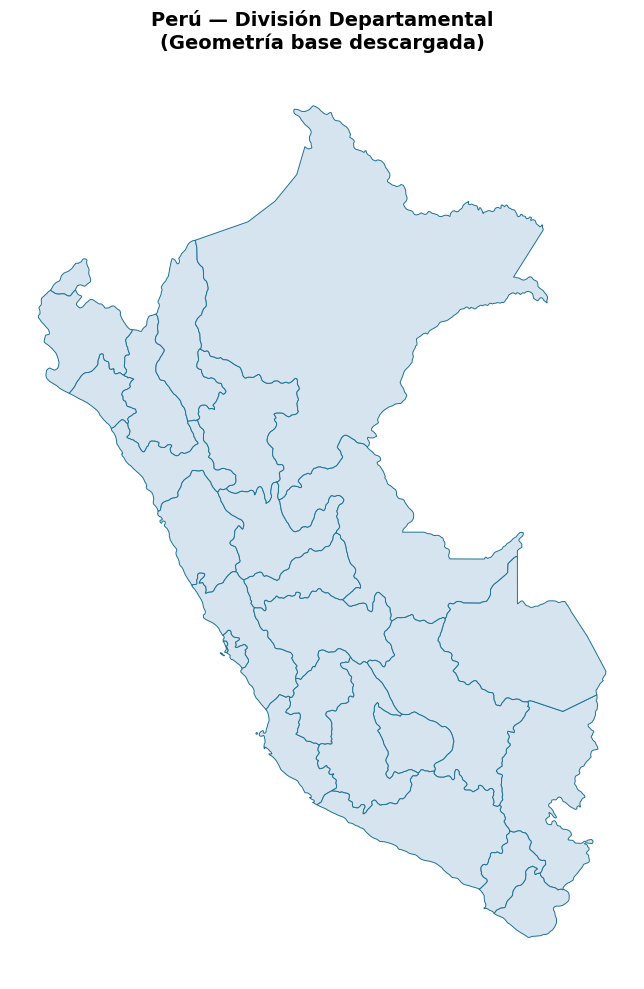

✅ Geometría cargada correctamente — 25 departamentos del Perú


In [22]:
# ─── PASO 6: Mapa base del Perú (verificar que la geometría cargó bien) ──────

fig, ax = plt.subplots(figsize=(8, 10))

dpto.plot(
    ax        = ax,
    color     = '#D6E4F0',
    edgecolor = '#1C7293',
    linewidth = 0.7
)

ax.set_title("Perú — División Departamental\n(Geometría base descargada)", 
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('peru_base.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Geometría cargada correctamente — 25 departamentos del Perú")


---
## 2️⃣  Cargar Datos Económicos — Tasa de Analfabetismo
**Fuente:** INEI — Encuesta Nacional de Hogares (ENAHO)  
**Archivo:** `tasa de analfabetismo.xlsx`


In [23]:
# ─── PASO 7: Cargar datos de Analfabetismo (PPT Slide 6 — Encoding) ──────────
# El encoding es clave: detectarlo con chardet antes de leer

ruta_analfabetismo = r"C:\Users\LENOVO\Documents\tasa de analfabetismo.xlsx"

try:
    analfabetismo = pd.read_excel(ruta_analfabetismo)
    print("✅ Archivo cargado desde ruta local")
    
except FileNotFoundError:
    # ─── DATOS DE MUESTRA (si no encuentra el archivo local) ─────────────────
    print("📋 Usando datos de muestra — reemplazar con archivo real")
    
    analfabetismo = pd.DataFrame({
        'Departamento': [
            'Huánuco','Cajamarca','Apurímac','Huancavelica','Cusco',
            'Ayacucho','Áncash','Puno','Amazonas','Piura',
            'San Martín','Junín','La Libertad','Pasco','Loreto',
            'Lambayeque','Tacna','Ucayali','Tumbes','Arequipa',
            'Moquegua','Ica','Madre de Dios','Prov. Const. Callao','Lima'
        ],
        'Porcentaje_2014': [
            13.4, 13.6, 16.0, 16.4, 10.0,
            13.4,  9.8,  9.4, 11.2,  9.4,
             8.9,  7.8,  8.0,  9.7,  8.4,
             7.9,  4.5,  6.0,  5.8,  4.1,
             4.7,  3.9,  4.8,  2.9,  2.8
        ],
        'Porcentaje_2024': [
            12.1, 12.8, 14.2, 14.8,  9.2,
            11.9,  8.7,  8.6, 10.5,  8.3,
             7.8,  6.8,  7.1,  8.5,  7.6,
             6.9,  3.8,  5.4,  5.0,  3.5,
             4.0,  3.4,  4.1,  2.4,  2.3
        ]
    })

print(f"\nDimensiones: {analfabetismo.shape[0]} filas × {analfabetismo.shape[1]} columnas")
display(analfabetismo.head(8))


✅ Archivo cargado desde ruta local

Dimensiones: 32 filas × 3 columnas


,Departamento,Porcentaje_2014,Porcentaje_2024
0,Huánuco,13.4,12.1
1,Cajamarca,13.1,10.6
2,Apurímac,17.1,10.2
3,Huancavelica,15.6,10.0
4,Cusco,12.7,9.1
5,Ayacucho,12.7,8.9
6,Áncash,9.1,7.3
7,Puno,10.5,7.0


In [24]:
# ─── PASO 8: Explorar tipos de datos ────────────────────────────────────────
print("Tipos de variables:")
print(analfabetismo.dtypes)
print()
print("Estadísticas descriptivas:")
display(analfabetismo.describe())


Tipos de variables:
Departamento        object
Porcentaje_2014    float64
Porcentaje_2024    float64
dtype: object

Estadísticas descriptivas:


,Porcentaje_2014,Porcentaje_2024
count,26.000000,26.000000
mean,7.619231,5.588462
std,4.265773,2.948671
min,1.900000,1.800000
25%,4.525000,3.725000
50%,6.300000,4.700000
75%,10.250000,7.225000
max,17.100000,12.100000


---
## 3️⃣  Estandarización de Nombres de Departamentos  
> 📌 **PPT Slide 8 — Merge:** Para que el merge funcione, ambas tablas deben tener los departamentos escritos de forma idéntica. Este es el paso más crítico.


In [25]:
# ─── PASO 9: Mapeo de nombres — clave para el merge ──────────────────────────
# El GeoJSON usa nombres propios del proveedor, los datos del INEI tienen otra forma
# Creamos un diccionario para estandarizar

# Primero: ver cómo viene el nombre en el GeoJSON
print("Nombres en GeoJSON:")
print(sorted(dpto['Departamento_geo'].tolist()))


Nombres en GeoJSON:
['Amazonas', 'Ancash', 'Apurímac', 'Arequipa', 'Ayacucho', 'Cajamarca', 'Cusco', 'El Callao', 'Huancavelica', 'Huánuco', 'Ica', 'Junín', 'La Libertad', 'Lambayeque', 'Lima', 'Loreto', 'Madre de Dios', 'Moquegua', 'Municipalidad Metropolitana de Lima', 'Pasco', 'Piura', 'Puno', 'San Martín', 'Tacna', 'Tumbes', 'Ucayali']


In [26]:
# ─── PASO 10: Crear diccionario de estandarización ───────────────────────────
# Ajusta este diccionario según lo que imprima el paso anterior

nombre_mapa = {
    # Nombre en GeoJSON     : Nombre en nuestros datos
    'Amazonas'              : 'Amazonas',
    'Ancash'                : 'Áncash',
    'Áncash'                : 'Áncash',
    'Apurimac'              : 'Apurímac',
    'Apurímac'              : 'Apurímac',
    'Arequipa'              : 'Arequipa',
    'Ayacucho'              : 'Ayacucho',
    'Cajamarca'             : 'Cajamarca',
    'Callao'                : 'Prov. Const. Callao',
    'Cusco'                 : 'Cusco',
    'Huancavelica'          : 'Huancavelica',
    'Huanuco'               : 'Huánuco',
    'Huánuco'               : 'Huánuco',
    'Ica'                   : 'Ica',
    'Junin'                 : 'Junín',
    'Junín'                 : 'Junín',
    'La Libertad'           : 'La Libertad',
    'Lambayeque'            : 'Lambayeque',
    'Lima'                  : 'Lima',
    'Loreto'                : 'Loreto',
    'Madre de Dios'         : 'Madre de Dios',
    'Moquegua'              : 'Moquegua',
    'Pasco'                 : 'Pasco',
    'Piura'                 : 'Piura',
    'Puno'                  : 'Puno',
    'San Martin'            : 'San Martín',
    'San Martín'            : 'San Martín',
    'Tacna'                 : 'Tacna',
    'Tumbes'                : 'Tumbes',
    'Ucayali'               : 'Ucayali',
}

# Aplicar el mapeo
dpto['Departamento'] = dpto['Departamento_geo'].map(nombre_mapa)

# Verificar
sin_mapeo = dpto[dpto['Departamento'].isna()]['Departamento_geo'].tolist()
if sin_mapeo:
    print(f"⚠️  Sin mapeo: {sin_mapeo} — agregar al diccionario")
else:
    print("✅ Todos los departamentos mapeados correctamente")

display(dpto[['Departamento_geo', 'Departamento']].head(8))


⚠️  Sin mapeo: ['El Callao', 'Municipalidad Metropolitana de Lima'] — agregar al diccionario


,Departamento_geo,Departamento
0,Puno,Puno
1,Tumbes,Tumbes
2,Piura,Piura
3,Lambayeque,Lambayeque
4,Cajamarca,Cajamarca
5,Amazonas,Amazonas
6,La Libertad,La Libertad
7,Ancash,Áncash


---
## 4️⃣  Merge: Unir Geometría con Datos Económicos  
> 📌 **PPT Slide 8:** El merge conecta la geometría (que tiene `geometry`) con los indicadores económicos. La columna de unión es el nombre del departamento estandarizado.


In [27]:
# ─── PASO 11: Mostrar las DOS tablas antes del merge ─────────────────────────
# (PPT Slide 8 — el diagrama de dos tablas que se unen)

print("=" * 55)
print("TABLA 1: GeoDataFrame (tiene geometry)")
print("=" * 55)
display(dpto[['Departamento', 'geometry']].head(5))

print("\n" + "=" * 55)
print("TABLA 2: Datos económicos (tiene indicadores)")
print("=" * 55)
display(analfabetismo.head(5))


TABLA 1: GeoDataFrame (tiene geometry)


,Departamento,geometry
0,Puno,"POLYGON ((-69.57987 -17.30313, -69.60561 -17.2..."
1,Tumbes,"POLYGON ((-80.49374 -4.07288, -80.49807 -4.058..."
2,Piura,"POLYGON ((-81.05565 -4.07968, -81.05807 -4.083..."
3,Lambayeque,"POLYGON ((-80.63906 -6.35623, -80.62161 -6.364..."
4,Cajamarca,"POLYGON ((-79.41533 -5.95522, -79.41209 -5.960..."



TABLA 2: Datos económicos (tiene indicadores)


,Departamento,Porcentaje_2014,Porcentaje_2024
0,Huánuco,13.4,12.1
1,Cajamarca,13.1,10.6
2,Apurímac,17.1,10.2
3,Huancavelica,15.6,10.0
4,Cusco,12.7,9.1


In [28]:
# ─── PASO 12: Ejecutar el MERGE ──────────────────────────────────────────────
# how='left' → conserva TODOS los distritos del shapefile
# Distritos sin datos → quedarán en NaN (se verán en gris en el mapa)

mapa_alfa = dpto.merge(
    analfabetismo,
    on  = 'Departamento',
    how = 'left'          # ← left join: mantiene toda la geometría
)

print(f"✅ Merge completado")
print(f"   Filas resultado: {len(mapa_alfa)}")
print(f"   Columnas: {list(mapa_alfa.columns)}")


✅ Merge completado
   Filas resultado: 34
   Columnas: ['Departamento_geo', 'geometry', 'Departamento', 'Porcentaje_2014', 'Porcentaje_2024']


In [29]:
# ─── PASO 13: Verificar missing values (PPT Slide 8 — advertencia) ───────────
# Un missing value = departamento sin dato → aparecerá en GRIS en el mapa

faltantes_2014 = mapa_alfa['Porcentaje_2014'].isna().sum()
faltantes_2024 = mapa_alfa['Porcentaje_2024'].isna().sum()

print(f"Missing values 2014: {faltantes_2014}")
print(f"Missing values 2024: {faltantes_2024}")

if faltantes_2014 > 0:
    print("\n⚠️  Departamentos sin datos:")
    print(mapa_alfa[mapa_alfa['Porcentaje_2014'].isna()]['Departamento'].tolist())
    print("   → Revisar estandarización de nombres en el diccionario")
else:
    print("\n✅ No hay missing values — merge perfecto")

display(mapa_alfa[['Departamento', 'Porcentaje_2014', 'Porcentaje_2024', 'geometry']].head(8))


Missing values 2014: 11
Missing values 2024: 11

⚠️  Departamentos sin datos:
['Lima', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
   → Revisar estandarización de nombres en el diccionario


,Departamento,Porcentaje_2014,Porcentaje_2024,geometry
0,Puno,10.5,7.0,"POLYGON ((-69.57987 -17.30313, -69.60561 -17.2..."
1,Tumbes,3.7,3.8,"POLYGON ((-80.49374 -4.07288, -80.49807 -4.058..."
2,Piura,7.7,5.7,"POLYGON ((-81.05565 -4.07968, -81.05807 -4.083..."
3,Lambayeque,6.3,4.1,"POLYGON ((-80.63906 -6.35623, -80.62161 -6.364..."
4,Cajamarca,13.1,10.6,"POLYGON ((-79.41533 -5.95522, -79.41209 -5.960..."
5,Amazonas,9.5,6.4,"POLYGON ((-77.99242 -6.97447, -77.94096 -6.963..."
6,La Libertad,6.0,4.9,"POLYGON ((-79.69893 -7.13293, -79.69229 -7.164..."
7,Áncash,9.1,7.3,"POLYGON ((-78.6529 -8.95611, -78.65847 -8.9879..."


---
## 5️⃣  MAPA 1 — Tasa de Analfabetismo 2014  
> Distribución del analfabetismo por departamento. Colores más oscuros = mayor tasa.


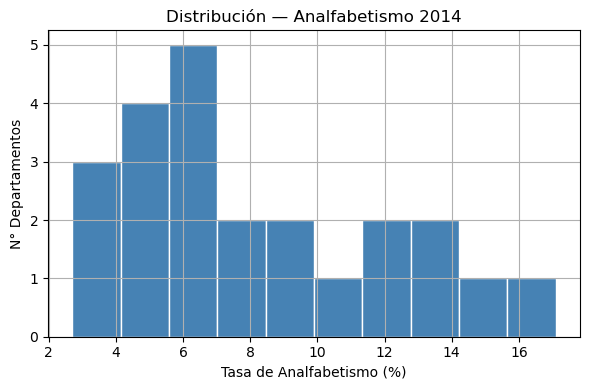

In [30]:
# ══════ MAPA 1: Tasa de Analfabetismo 2014 ═══════════════════════════════════
# Verificar distribución antes de graficar (PPT Slide → buenas prácticas)
fig, ax = plt.subplots(figsize=(6, 4))
mapa_alfa['Porcentaje_2014'].hist(bins=10, color='steelblue', edgecolor='white', ax=ax)
ax.set_title("Distribución — Analfabetismo 2014", fontsize=12)
ax.set_xlabel("Tasa de Analfabetismo (%)")
ax.set_ylabel("N° Departamentos")
plt.tight_layout()
plt.show()


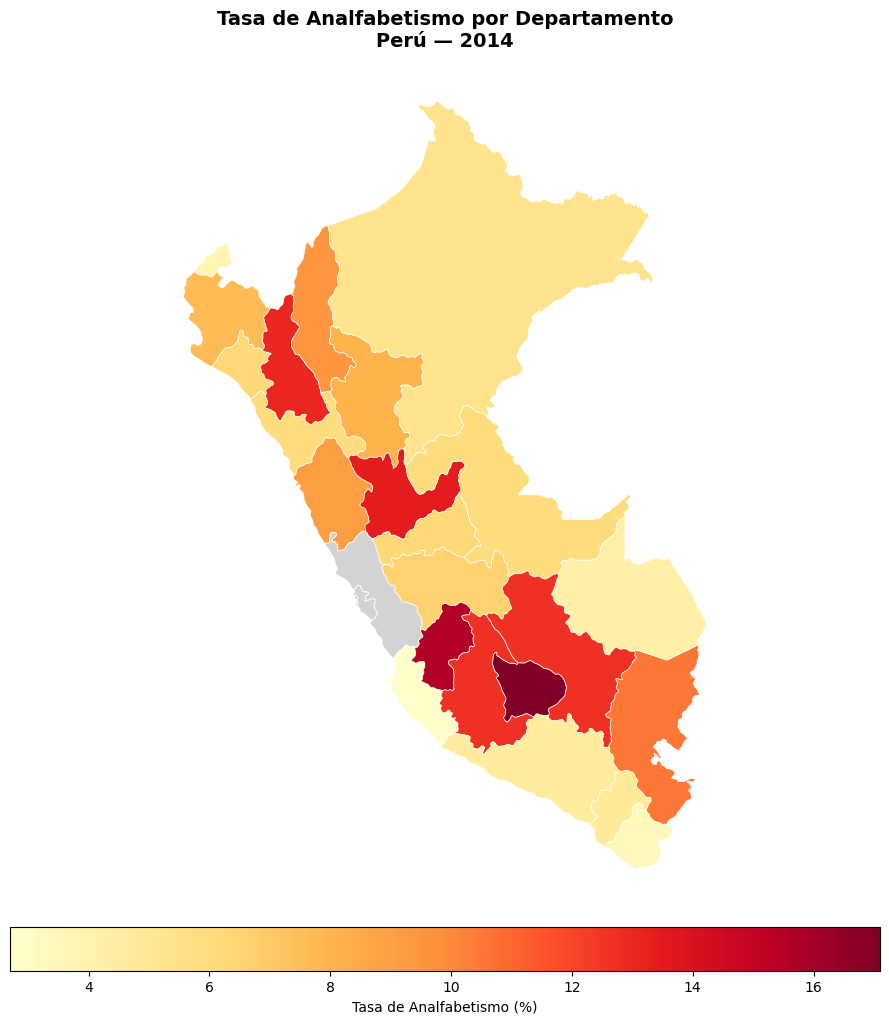

💾 Guardado: mapa_analfabetismo_2014.png


In [31]:
# ══════ MAPA 1: Choropleth — Analfabetismo 2014 ══════════════════════════════
fig, ax = plt.subplots(figsize=(9, 11))

mapa_alfa.plot(
    column         = 'Porcentaje_2014',
    cmap           = 'YlOrRd',          # Amarillo → Naranja → Rojo
    legend         = True,
    legend_kwds    = {'label': 'Tasa de Analfabetismo (%)', 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor      = 'white',
    linewidth      = 0.5,
    missing_kwds   = {'color': 'lightgrey', 'label': 'Sin dato'},
    ax             = ax
)

ax.set_title("Tasa de Analfabetismo por Departamento\nPerú — 2014",
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('mapa_analfabetismo_2014.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: mapa_analfabetismo_2014.png")


## 6️⃣  MAPA 2 — Tasa de Analfabetismo 2024  
> Evolución de la tasa 10 años después.


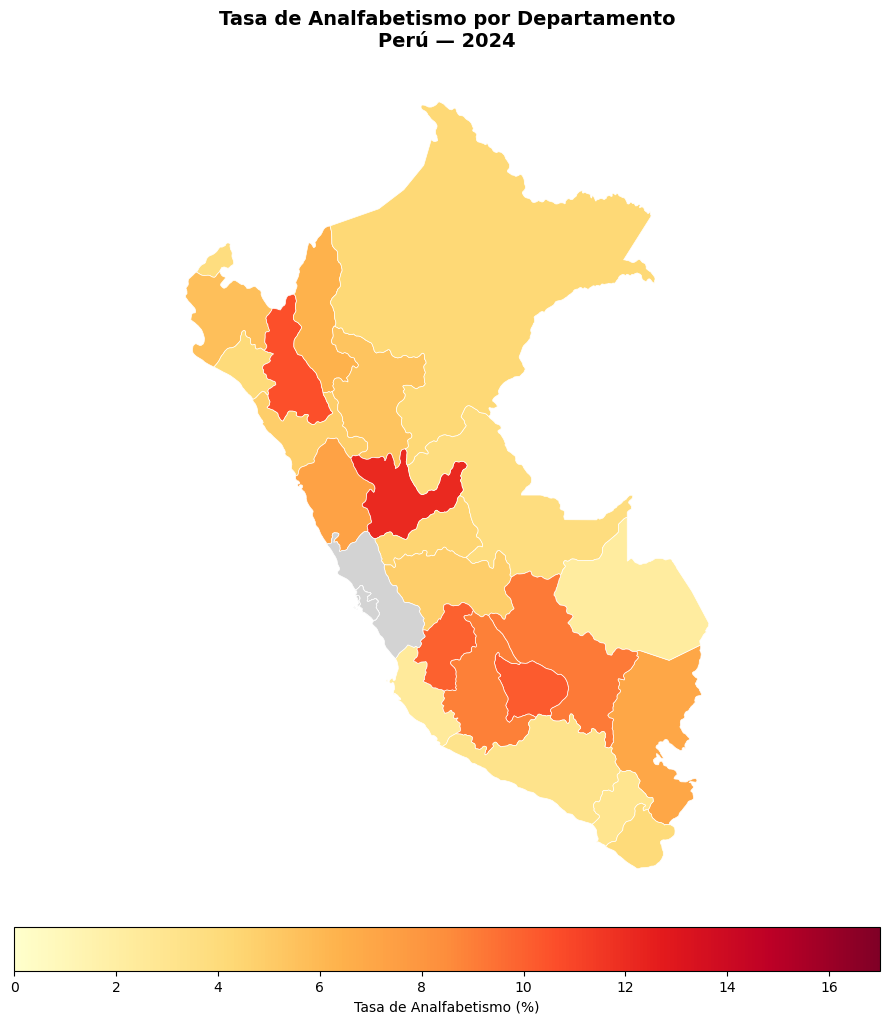

💾 Guardado: mapa_analfabetismo_2024.png


In [32]:
# ══════ MAPA 2: Choropleth — Analfabetismo 2024 ══════════════════════════════
fig, ax = plt.subplots(figsize=(9, 11))

mapa_alfa.plot(
    column         = 'Porcentaje_2024',
    cmap           = 'YlOrRd',
    legend         = True,
    legend_kwds    = {'label': 'Tasa de Analfabetismo (%)', 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor      = 'white',
    linewidth      = 0.5,
    missing_kwds   = {'color': 'lightgrey', 'label': 'Sin dato'},
    vmin           = 0, vmax = 17,      # ← misma escala que 2014 para comparar
    ax             = ax
)

ax.set_title("Tasa de Analfabetismo por Departamento\nPerú — 2024",
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('mapa_analfabetismo_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: mapa_analfabetismo_2024.png")


## 7️⃣  MAPA 3 — Comparación 2014 vs 2024 (subplots)  
> Mostrar dos mapas lado a lado con la misma escala de color para facilitar la comparación.


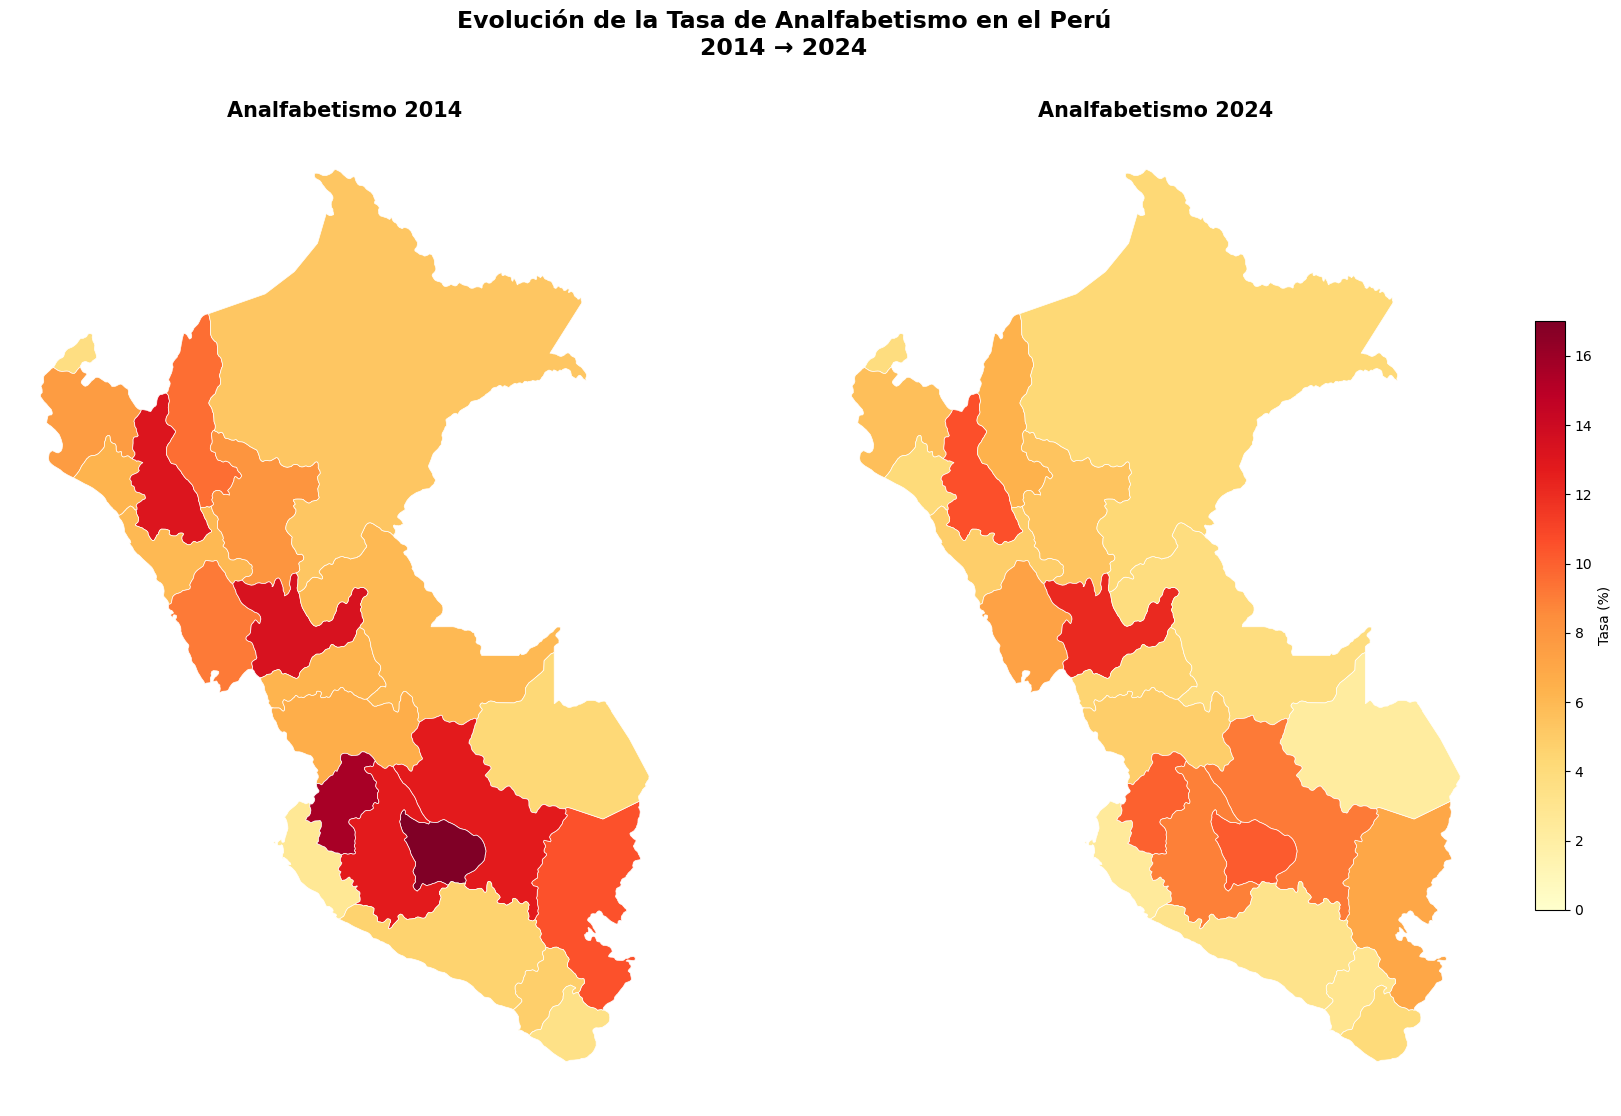

💾 Guardado: mapa_analfabetismo_comparacion.png


In [33]:
# ══════ MAPA 3: Comparación 2014 vs 2024 — subplots ══════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 11))

vmin, vmax = 0, 17   # escala fija para comparar

for ax, año, col in zip(axes, [2014, 2024], ['Porcentaje_2014', 'Porcentaje_2024']):
    
    mapa_alfa.plot(
        column       = col,
        cmap         = 'YlOrRd',
        legend       = (ax == axes[1]),      # leyenda solo en el derecho
        legend_kwds  = {'label': 'Tasa (%)', 'orientation': 'vertical', 'shrink': 0.6},
        edgecolor    = 'white',
        linewidth    = 0.5,
        vmin         = vmin, vmax = vmax,
        ax           = ax
    )
    
    ax.set_title(f"Analfabetismo {año}", fontsize=15, fontweight='bold')
    ax.axis('off')

fig.suptitle("Evolución de la Tasa de Analfabetismo en el Perú\n2014 → 2024",
             fontsize=17, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('mapa_analfabetismo_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: mapa_analfabetismo_comparacion.png")


---
## 8️⃣  Centroides y Etiquetas en el Mapa  
> 📌 **PPT Slide 9:** El centroide es el punto geométrico central de un polígono. Para calcularlo correctamente se reproyecta a UTM (metros), se calcula el centroide, y se vuelve a WGS-84.


In [34]:
# ─── PASO 14: Calcular centroides correctamente (PPT Slide 9) ────────────────
# ① Reproyectar a UTM Perú (metros)
# ② Calcular centroide
# ③ Volver a WGS-84 para graficar

mapa_alfa['centroid'] = (
    mapa_alfa['geometry']
    .to_crs('EPSG:24891')   # ① → Sistema de coordenadas en METROS (UTM Perú)
    .centroid               # ② → Calcular punto central
    .to_crs('EPSG:4326')    # ③ → Volver a grados decimales (WGS-84)
)

print("✅ Centroides calculados")
print("   Ejemplo — Lima:")
lima_row = mapa_alfa[mapa_alfa['Departamento'] == 'Lima']['centroid']
if not lima_row.empty:
    pt = lima_row.iloc[0]
    print(f"   Latitud: {pt.y:.4f}  |  Longitud: {pt.x:.4f}")


✅ Centroides calculados
   Ejemplo — Lima:
   Latitud: -11.7735  |  Longitud: -76.6081


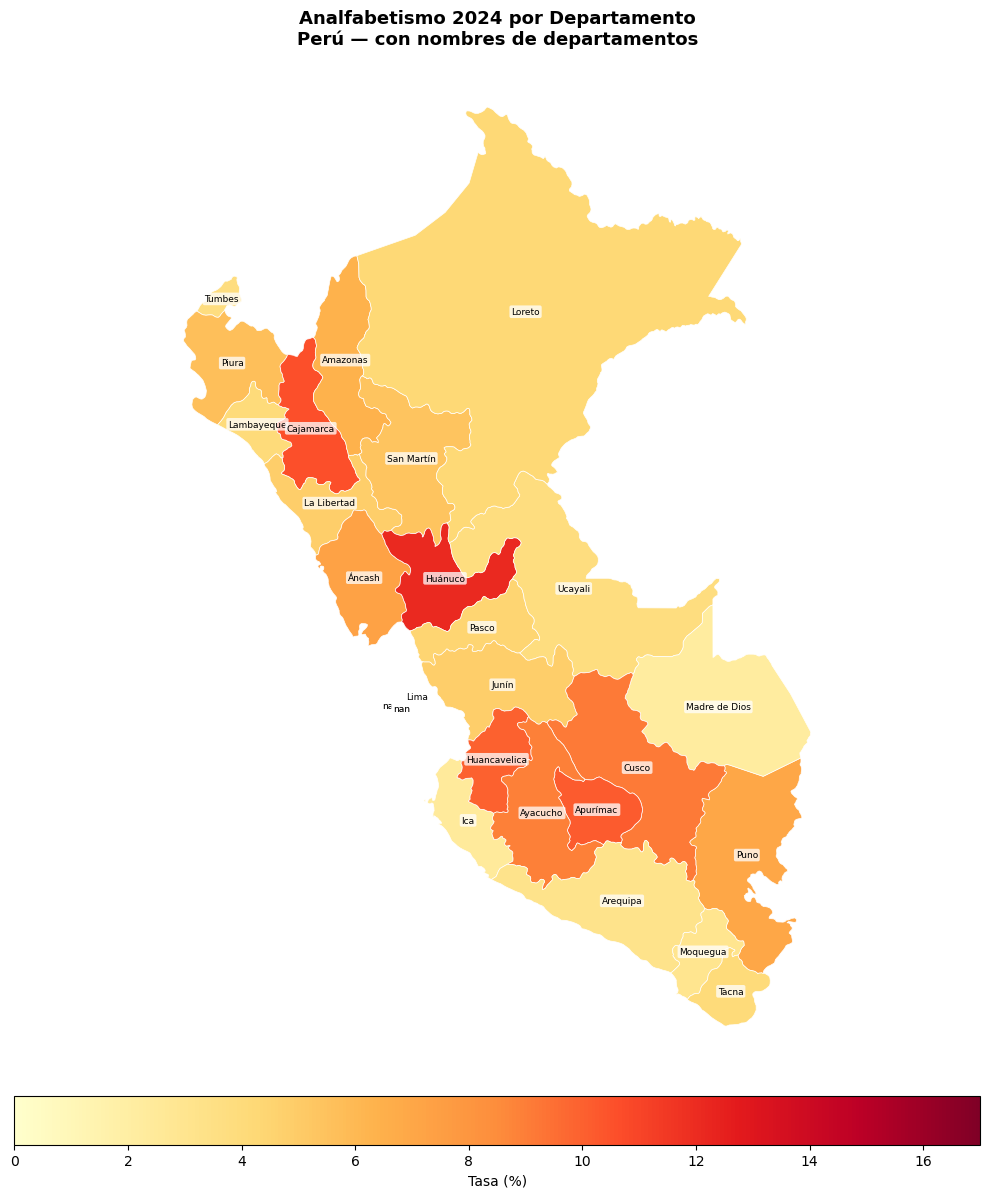

💾 Guardado: mapa_analfabetismo_etiquetas.png


In [35]:
# ══════ MAPA 4: Analfabetismo 2024 + Etiquetas de Departamentos ══════════════
fig, ax = plt.subplots(figsize=(10, 13))

mapa_alfa.plot(
    column       = 'Porcentaje_2024',
    cmap         = 'YlOrRd',
    legend       = True,
    legend_kwds  = {'label': 'Tasa (%)', 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor    = 'white',
    linewidth    = 0.5,
    vmin         = 0, vmax = 17,
    ax           = ax
)

# Agregar etiqueta en cada centroide
props = dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none')

for _, row in mapa_alfa.iterrows():
    if row['centroid'] is not None and row['Departamento'] is not None:
        # Nombre corto para evitar superposición
        nombre = str(row['Departamento']).replace('Prov. Const. ', '').replace(' Metropolitana', ' Metro')
        ax.annotate(
            text   = nombre,
            xy     = (row['centroid'].x, row['centroid'].y),
            ha     = 'center', va = 'center',
            fontsize = 6.5,
            bbox     = props
        )

ax.set_title("Analfabetismo 2024 por Departamento\nPerú — con nombres de departamentos",
             fontsize=13, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('mapa_analfabetismo_etiquetas.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: mapa_analfabetismo_etiquetas.png")


---
## 9️⃣  MAPA 5 — Siembra de Coca  
**Fuente:** `siembra de coca_hasta_2024.xlsx`  
> Análisis de superficie cultivada de hoja de coca por departamento.


In [56]:
# ─── Leer el archivo de Siembra de Coca (formato real del Excel) ─────────────

ruta_coca = r"C:\Users\LENOVO\Documents\siembra de coca_hasta_2024.xlsx"

# El Excel tiene: fila vacía en row 0, columna extra sin nombre (Unnamed: 1)
coca_raw = pd.read_excel(ruta_coca, header=0)

print("─── Tabla cruda (como viene del Excel) ─────────────────────")
display(coca_raw)

print(f"\nColumnas detectadas: {list(coca_raw.columns)}")
print(f"Filas: {coca_raw.shape[0]}")


─── Tabla cruda (como viene del Excel) ─────────────────────


,Período,Unnamed: 1,2018,2019,2020,2017,2023,2021,2022,2024
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMAZONAS,NaN,626,635,640,714,1 443,1 564,1 641,1 818
2,AYACUCHO,NaN,14 304,15 812,17 786,12 894,20 052,18 590,18 469,18 749
3,CAJAMARCA,NaN,372,372,384,382,191,406,432,209
4,CUSCO,NaN,14 189,13 307,12 363,38 878,15 099,13 642,16 010,14 493
5,HUANUCO,NaN,1 128,1 063,1 707,749,4 960,3 221,3 887,4 627
6,JUNIN,NaN,3 971,4 454,4 882,3 609,8 921,6 701,8 063,8 883
7,LA LIBERTAD,NaN,NaN,NaN,602,1 153,649,1 193,1 128,659
8,LORETO,NaN,5 003,4 955,6 327,3 340,12 491,10 348,13 846,12 409
9,MADRE DE DIOS,NaN,36,42,57,29,1 529,315,1 014,1 476



Columnas detectadas: ['Período', 'Unnamed: 1', 2018, 2019, 2020, 2017, 2023, 2021, 2022, 2024]
Filas: 15


In [57]:
# ─── Limpiar estructura del Excel ────────────────────────────────────────────

# 1. Renombrar columna principal
coca_raw = coca_raw.rename(columns={'Período': 'Departamento'})

# 2. Eliminar la columna vacía (Unnamed: 1)
coca_raw = coca_raw.drop(columns=[col for col in coca_raw.columns if 'Unnamed' in str(col)])

# 3. Eliminar la fila 0 vacía (NaN) y la fila "Totales"
coca_clean = coca_raw.dropna(subset=['Departamento'])          # elimina fila NaN
coca_clean = coca_clean[~coca_clean['Departamento'].str.strip().str.upper().eq('TOTALES')]
coca_clean = coca_clean.reset_index(drop=True)

print("─── Tabla limpia ────────────────────────────────────────────")
display(coca_clean)
print(f"\nDepartamentos: {len(coca_clean)}")

─── Tabla limpia ────────────────────────────────────────────


,Departamento,2018,2019,2020,2017,2023,2021,2022,2024
0,AMAZONAS,626,635,640,714,1 443,1 564,1 641,1 818
1,AYACUCHO,14 304,15 812,17 786,12 894,20 052,18 590,18 469,18 749
2,CAJAMARCA,372,372,384,382,191,406,432,209
3,CUSCO,14 189,13 307,12 363,38 878,15 099,13 642,16 010,14 493
4,HUANUCO,1 128,1 063,1 707,749,4 960,3 221,3 887,4 627
5,JUNIN,3 971,4 454,4 882,3 609,8 921,6 701,8 063,8 883
6,LA LIBERTAD,NaN,NaN,602,1 153,649,1 193,1 128,659
7,LORETO,5 003,4 955,6 327,3 340,12 491,10 348,13 846,12 409
8,MADRE DE DIOS,36,42,57,29,1 529,315,1 014,1 476
9,PASCO,233,318,1 153,782,1 561,1 835,2 117,1 207



Departamentos: 13


In [58]:
# ─── Convertir "1 443" → 1443 (espacio como separador de miles) ──────────────
# Los valores vienen como string con espacio: "14 304" → necesitamos int 14304

años = [col for col in coca_clean.columns if col != 'Departamento']
print(f"Años disponibles: {sorted(años)}")

for año in años:
    coca_clean[año] = (
        coca_clean[año]
        .astype(str)
        .str.replace(' ', '', regex=False)   # quitar espacios de miles
        .str.replace('\xa0', '', regex=False) # quitar espacios especiales
        .str.strip()
        .replace('nan', None)
        .replace('', None)
    )
    coca_clean[año] = pd.to_numeric(coca_clean[año], errors='coerce')

print("\n─── Tipos de datos después de conversión ─────────────────────")
print(coca_clean.dtypes)

display(coca_clean)

Años disponibles: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

─── Tipos de datos después de conversión ─────────────────────
Departamento     object
2018            float64
2019            float64
2020              int64
2017              int64
2023              int64
2021              int64
2022              int64
2024              int64
dtype: object


,Departamento,2018,2019,2020,2017,2023,2021,2022,2024
0,AMAZONAS,626.0,635.0,640,714,1443,1564,1641,1818
1,AYACUCHO,14304.0,15812.0,17786,12894,20052,18590,18469,18749
2,CAJAMARCA,372.0,372.0,384,382,191,406,432,209
3,CUSCO,14189.0,13307.0,12363,38878,15099,13642,16010,14493
4,HUANUCO,1128.0,1063.0,1707,749,4960,3221,3887,4627
5,JUNIN,3971.0,4454.0,4882,3609,8921,6701,8063,8883
6,LA LIBERTAD,NaN,NaN,602,1153,649,1193,1128,659
7,LORETO,5003.0,4955.0,6327,3340,12491,10348,13846,12409
8,MADRE DE DIOS,36.0,42.0,57,29,1529,315,1014,1476
9,PASCO,233.0,318.0,1153,782,1561,1835,2117,1207


In [59]:
# ─── Reordenar columnas por año cronológico ───────────────────────────────────
años_sorted = sorted([col for col in coca_clean.columns if col != 'Departamento'])

coca_clean = coca_clean[['Departamento'] + años_sorted]

print("Años disponibles en orden:", años_sorted)
print()

# Estadísticas descriptivas — verificar que los números están bien
display(coca_clean.describe())

Años disponibles en orden: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]



,2017,2018,2019,2020,2021,2022,2023,2024
count,13.000000,12.000000,12.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,5495.846154,3888.666667,4219.333333,4582.153846,6206.307692,7308.307692,7137.230769,6904.153846
std,10636.321167,5099.379861,5341.438525,5456.763584,5929.395281,6650.917711,6591.457137,6293.938113
min,29.000000,36.000000,42.000000,57.000000,315.000000,432.000000,191.000000,209.000000
25%,749.000000,562.500000,569.250000,640.000000,1564.000000,1641.000000,1529.000000,1476.000000
50%,1153.000000,1846.500000,1399.500000,1707.000000,3221.000000,3887.000000,4960.000000,4627.000000
75%,3609.000000,4229.000000,5493.000000,6327.000000,10348.000000,13846.000000,12221.000000,11904.000000
max,38878.000000,14304.000000,15812.000000,17786.000000,18590.000000,18469.000000,20052.000000,18749.000000


In [60]:
# ─── Los nombres vienen en MAYÚSCULAS → mapear al formato del GeoJSON ─────────

nombre_mapa_coca = {
    'AMAZONAS'    : 'Amazonas',
    'AYACUCHO'    : 'Ayacucho',
    'CAJAMARCA'   : 'Cajamarca',
    'CUSCO'       : 'Cusco',
    'HUANUCO'     : 'Huánuco',
    'JUNIN'       : 'Junín',
    'LA LIBERTAD' : 'La Libertad',
    'LORETO'      : 'Loreto',
    'MADRE DE DIOS': 'Madre de Dios',
    'PASCO'       : 'Pasco',
    'PUNO'        : 'Puno',
    'SAN MARTIN'  : 'San Martín',
    'UCAYALI'     : 'Ucayali',
}

# Limpiar y mapear
coca_clean['Departamento'] = (
    coca_clean['Departamento']
    .str.strip()
    .str.upper()
    .map(nombre_mapa_coca)
)

# Ver cuáles quedaron sin mapeo
sin_mapeo = coca_clean[coca_clean['Departamento'].isna()]
if len(sin_mapeo) > 0:
    print(f"⚠️  Sin mapeo: {sin_mapeo.index.tolist()}")
else:
    print("✅ Todos los departamentos mapeados")

display(coca_clean)

✅ Todos los departamentos mapeados


,Departamento,2017,2018,2019,2020,2021,2022,2023,2024
0,Amazonas,714,626.0,635.0,640,1564,1641,1443,1818
1,Ayacucho,12894,14304.0,15812.0,17786,18590,18469,20052,18749
2,Cajamarca,382,372.0,372.0,384,406,432,191,209
3,Cusco,38878,14189.0,13307.0,12363,13642,16010,15099,14493
4,Huánuco,749,1128.0,1063.0,1707,3221,3887,4960,4627
5,Junín,3609,3971.0,4454.0,4882,6701,8063,8921,8883
6,La Libertad,1153,NaN,NaN,602,1193,1128,649,659
7,Loreto,3340,5003.0,4955.0,6327,10348,13846,12491,12409
8,Madre de Dios,29,36.0,42.0,57,315,1014,1529,1476
9,Pasco,782,233.0,318.0,1153,1835,2117,1561,1207


In [62]:
# ─── Merge: geometría + siembra de coca ──────────────────────────────────────
# Los departamentos SIN coca (Lima, Arequipa, etc.) tendrán NaN → aparecerán en gris

mapa_coca = dpto.merge(coca_clean, on='Departamento', how='left')

print(f"Filas después del merge: {len(mapa_coca)}")
print()

# Departamentos SIN datos de coca (correcto, no producen)
sin_coca = mapa_coca[mapa_coca[2024].isna()]['Departamento'].tolist()
print(f"Departamentos sin coca (NaN → gris en mapa): {sin_coca}")

Filas después del merge: 26

Departamentos sin coca (NaN → gris en mapa): ['Tumbes', 'Piura', 'Lambayeque', 'Áncash', 'Lima', nan, nan, 'Ica', 'Huancavelica', 'Apurímac', 'Arequipa', 'Moquegua', 'Tacna']


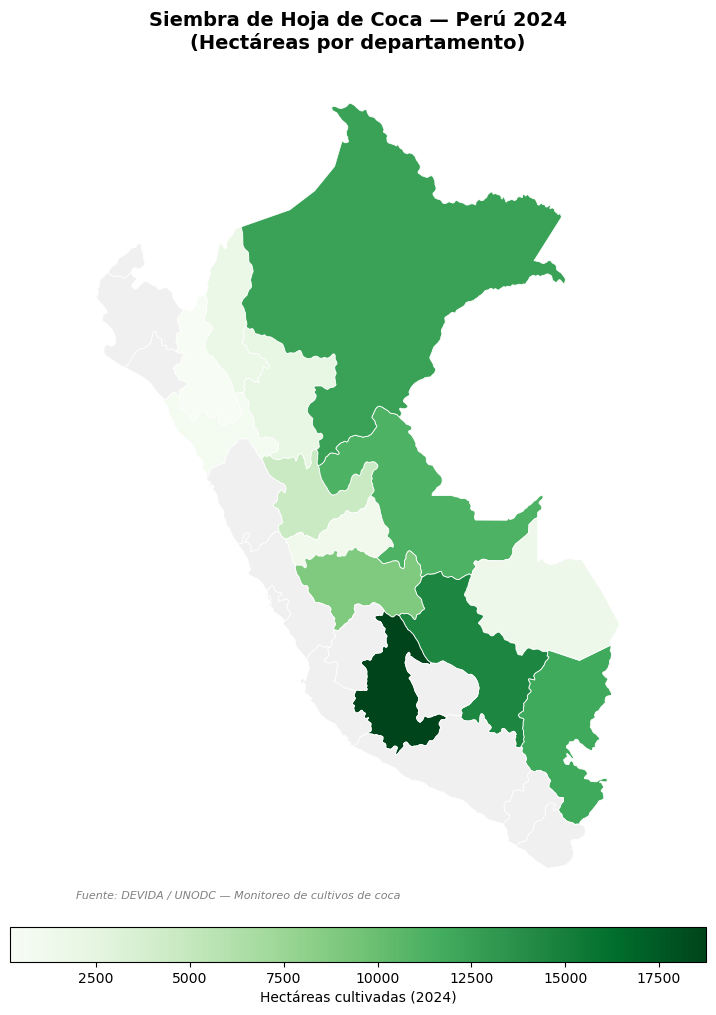

💾 Guardado: mapa_coca_2024.png


In [63]:
# ══════ MAPA — Siembra de Hoja de Coca (hectáreas) ═══════════════════════════

año_mapa = 2024   # ← cambiar aquí para otros años

fig, ax = plt.subplots(figsize=(9, 11))

mapa_coca.plot(
    column       = año_mapa,
    cmap         = 'Greens',
    legend       = True,
    legend_kwds  = {
        'label'       : f'Hectáreas cultivadas ({año_mapa})',
        'orientation' : 'horizontal',
        'pad'         : 0.02,
        'shrink'      : 0.8
    },
    edgecolor    = 'white',
    linewidth    = 0.6,
    missing_kwds = {
        'color' : '#F0F0F0',       # gris claro = sin cultivo
        'label' : 'Sin cultivo'
    },
    ax           = ax
)

ax.set_title(f"Siembra de Hoja de Coca — Perú {año_mapa}\n(Hectáreas por departamento)",
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')

# Nota de fuente
ax.text(0.01, 0.01,
        "Fuente: DEVIDA / UNODC — Monitoreo de cultivos de coca",
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig(f'mapa_coca_{año_mapa}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Guardado: mapa_coca_{año_mapa}.png")

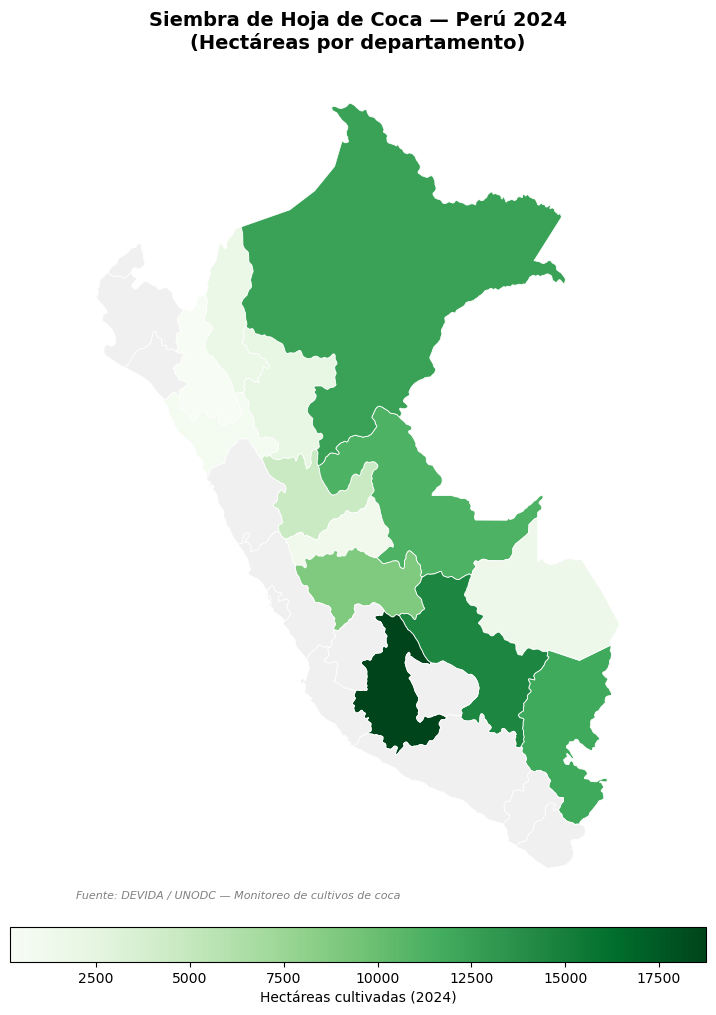

💾 Guardado: mapa_coca_2024.png


In [64]:
# ══════ MAPA — Siembra de Hoja de Coca (hectáreas) ═══════════════════════════

año_mapa = 2024   # ← cambiar aquí para otros años

fig, ax = plt.subplots(figsize=(9, 11))

mapa_coca.plot(
    column       = año_mapa,
    cmap         = 'Greens',
    legend       = True,
    legend_kwds  = {
        'label'       : f'Hectáreas cultivadas ({año_mapa})',
        'orientation' : 'horizontal',
        'pad'         : 0.02,
        'shrink'      : 0.8
    },
    edgecolor    = 'white',
    linewidth    = 0.6,
    missing_kwds = {
        'color' : '#F0F0F0',       # gris claro = sin cultivo
        'label' : 'Sin cultivo'
    },
    ax           = ax
)

ax.set_title(f"Siembra de Hoja de Coca — Perú {año_mapa}\n(Hectáreas por departamento)",
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')

# Nota de fuente
ax.text(0.01, 0.01,
        "Fuente: DEVIDA / UNODC — Monitoreo de cultivos de coca",
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig(f'mapa_coca_{año_mapa}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Guardado: mapa_coca_{año_mapa}.png")

---
## 🔟  MAPA 6 — Presupuesto de Carreteras  
**Fuente:** `presupuesto_carretera_2024.xlsx`  
**Columnas:** `Departamento | PIM al 31 Dic | Devengado (Acum.) | % Avance (Devengado)`


In [38]:
# ─── PASO 17: Cargar datos de Presupuesto Carreteras ─────────────────────────
ruta_carreteras = r"C:\Users\LENOVO\Documents\presupuesto_carretera_2024.xlsx"

try:
    carreteras = pd.read_excel(ruta_carreteras)
    print("✅ Cargado desde ruta local")
    display(carreteras.head())
    
except FileNotFoundError:
    print("📋 Usando datos de muestra (formato del archivo real)")
    carreteras = pd.DataFrame({
        'Departamento': [
            'Amazonas','Áncash','Apurímac','Arequipa','Ayacucho',
            'Cajamarca','Prov. Const. Callao','Cusco','Huancavelica','Huánuco',
            'Ica','Junín','La Libertad','Lambayeque','Lima',
            'Loreto','Madre de Dios','Moquegua','Pasco','Piura',
            'Puno','San Martín','Tacna','Tumbes','Ucayali'
        ],
        'PIM_mill': [
            274, 433, 312, 524, 389,
            418, 85, 612, 298, 387,
            341, 498, 562, 287, 1243,
            356, 189, 214, 267, 598,
            487, 423, 198, 143, 312
        ],
        'Devengado_mill': [
            255, 420, 290, 498, 365,
            388, 81, 578, 271, 352,
            321, 462, 531, 268, 1187,
            312, 172, 201, 248, 561,
            445, 391, 186, 135, 289
        ],
        'Pct_Avance': [
            93.1, 97.1, 92.9, 95.0, 93.8,
            92.8, 95.3, 94.4, 91.0, 90.9,
            94.1, 92.8, 94.5, 93.4, 95.5,
            87.6, 91.0, 93.9, 92.9, 93.7,
            91.4, 92.4, 93.9, 94.4, 92.6
        ]
    })
    display(carreteras.head())


✅ Cargado desde ruta local


,Departamento,PIM al 31 Dic,Devengado (Acum.),% Avance (Devengado)
0,TOTAL,11 572,11 212,0.9690
1,Amazonas,274,255,0.9303
2,Ancash,433,420,0.9712
3,Apurímac,239,234,0.9800
4,Arequipa,149,146,0.9823


In [39]:
# ─── PASO 18: Limpiar el % Avance (puede venir como texto "96.90%") ──────────
# Si el archivo tiene formato texto, convertir a número:
if carreteras['Pct_Avance'].dtype == object:
    carreteras['Pct_Avance'] = (
        carreteras['Pct_Avance']
        .str.replace('%', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )
    print("✅ % Avance convertido a número")

# Merge
mapa_carr = dpto.merge(carreteras, on='Departamento', how='left')
print(f"Missing: {mapa_carr['Pct_Avance'].isna().sum()}")


KeyError: 'Pct_Avance'

NameError: name 'mapa_carr' is not defined

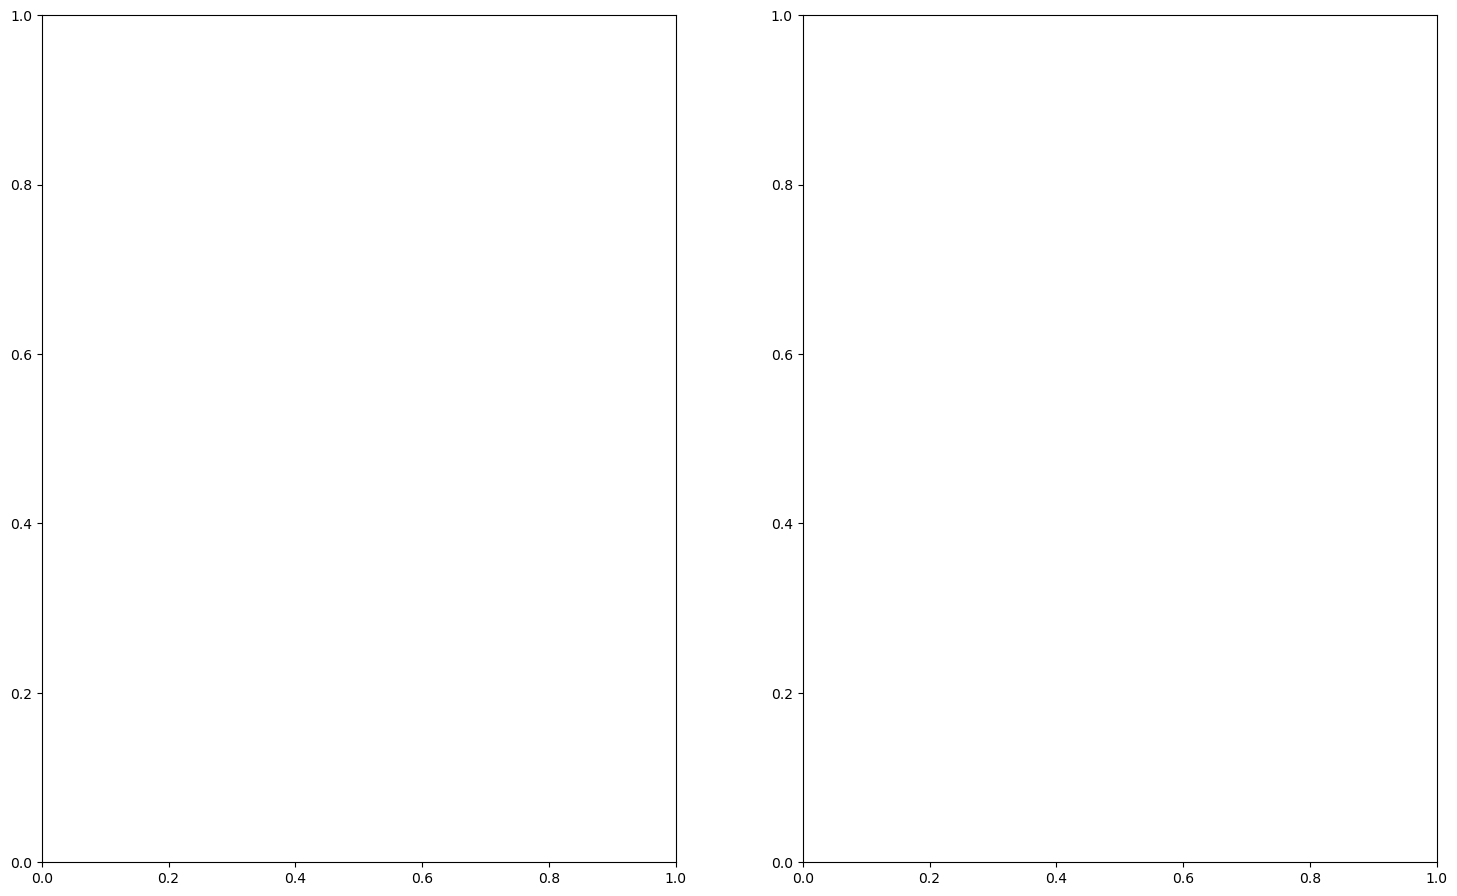

In [40]:
# ══════ MAPA 6: % Avance del Presupuesto de Carreteras 2024 ══════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 11))

# Subplot 1: PIM (presupuesto asignado)
mapa_carr.plot(
    column       = 'PIM_mill',
    cmap         = 'Blues',
    legend       = True,
    legend_kwds  = {'label': 'PIM (millones S/.)', 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor    = 'white', linewidth = 0.4,
    missing_kwds = {'color': 'lightgrey'},
    ax           = axes[0]
)
axes[0].set_title("PIM Carreteras 2024\n(millones de soles)", fontsize=13, fontweight='bold')
axes[0].axis('off')

# Subplot 2: % Avance de ejecución
mapa_carr.plot(
    column       = 'Pct_Avance',
    cmap         = 'RdYlGn',       # Rojo=bajo avance, Verde=alto avance
    legend       = True,
    legend_kwds  = {'label': '% Avance Devengado', 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor    = 'white', linewidth = 0.4,
    vmin = 85, vmax = 100,
    missing_kwds = {'color': 'lightgrey'},
    ax           = axes[1]
)
axes[1].set_title("% Avance Ejecución Carreteras\nDevengado / PIM × 100", fontsize=13, fontweight='bold')
axes[1].axis('off')

fig.suptitle("Presupuesto de Carreteras por Departamento — Perú 2024",
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('mapa_carreteras_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: mapa_carreteras_2024.png")


---
## 1️⃣1️⃣  MAPA 7 — Latencia de Internet  
**Fuente:** `latencia_internet.xlsx`


In [41]:
# ─── PASO 19: Cargar datos de Latencia Internet ──────────────────────────────
ruta_internet = r"C:\Users\LENOVO\Documents\latencia_internet.xlsx"

try:
    internet = pd.read_excel(ruta_internet)
    print("✅ Cargado")
    display(internet.head())
    
except FileNotFoundError:
    print("📋 Datos de muestra — latencia promedio en ms")
    internet = pd.DataFrame({
        'Departamento': [
            'Huánuco','Cajamarca','Apurímac','Huancavelica','Cusco',
            'Ayacucho','Áncash','Puno','Amazonas','Piura',
            'San Martín','Junín','La Libertad','Pasco','Loreto',
            'Lambayeque','Tacna','Ucayali','Tumbes','Arequipa',
            'Moquegua','Ica','Madre de Dios','Prov. Const. Callao','Lima'
        ],
        'Latencia_ms': [
            87, 92, 105, 118, 78,
            98, 75, 93, 112, 68,
            88, 82, 71, 94, 125,
            69, 62, 115, 65, 58,
            61, 64, 128, 42, 38
        ]
    })
    display(internet.head())


✅ Cargado


,Latencia de Internet Móvil por Región (ms),Unnamed: 1
0,Región,Latencia (ms)
1,Callao,51.53
2,Lima,51.87
3,Junín,56.55
4,Ica,57.54


In [42]:
# ─── PASO 20: Merge + Mapa Latencia Internet ─────────────────────────────────
mapa_int = dpto.merge(internet, on='Departamento', how='left')
print(f"Missing: {mapa_int['Latencia_ms'].isna().sum()}")


KeyError: 'Departamento'

NameError: name 'mapa_int' is not defined

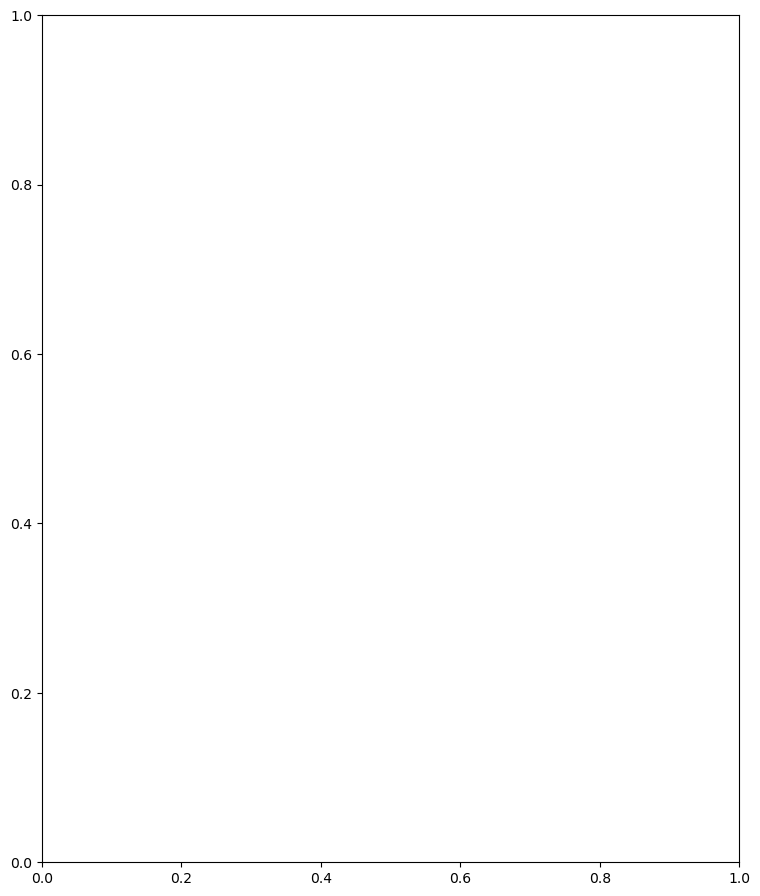

In [43]:
# ══════ MAPA 7: Latencia de Internet ═════════════════════════════════════════
# Mayor latencia = peor conexión → color más oscuro
fig, ax = plt.subplots(figsize=(9, 11))

mapa_int.plot(
    column       = 'Latencia_ms',
    cmap         = 'RdYlBu_r',     # Azul=baja latencia(bueno), Rojo=alta(malo)
    legend       = True,
    legend_kwds  = {'label': 'Latencia promedio (ms)', 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor    = 'white', linewidth = 0.5,
    missing_kwds = {'color': 'lightgrey', 'label': 'Sin dato'},
    ax           = ax
)

ax.set_title("Latencia de Internet por Departamento\nPerú — (ms — menor es mejor)",
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
ax.text(0.01, 0.01, "🔵 Azul = baja latencia (mejor conexión)   🔴 Rojo = alta latencia (peor)",
        transform=ax.transAxes, fontsize=9, color='#333333')
plt.tight_layout()
plt.savefig('mapa_latencia_internet.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: mapa_latencia_internet.png")


---
## 1️⃣2️⃣  MAPA 8 — Porcentaje de Delincuencia  
**Fuente:** `delicuencia_en%.xlsx`  
**Fuente referencial:** INEI DataCrim — `datacrim.inei.gob.pe`


In [44]:
# ─── PASO 21: Cargar datos de Delincuencia ───────────────────────────────────
ruta_delincuencia = r"C:\Users\LENOVO\Documents\delicuencia_en%.xlsx"

try:
    delincuencia = pd.read_excel(ruta_delincuencia)
    print("✅ Cargado")
    display(delincuencia.head())
    
except FileNotFoundError:
    print("📋 Datos de muestra — % hogares víctimas de algún hecho delictivo")
    delincuencia = pd.DataFrame({
        'Departamento': [
            'Huánuco','Cajamarca','Apurímac','Huancavelica','Cusco',
            'Ayacucho','Áncash','Puno','Amazonas','Piura',
            'San Martín','Junín','La Libertad','Pasco','Loreto',
            'Lambayeque','Tacna','Ucayali','Tumbes','Arequipa',
            'Moquegua','Ica','Madre de Dios','Prov. Const. Callao','Lima'
        ],
        'Pct_victimas_2022': [
            23.4, 21.8, 20.1, 17.5, 27.8,
            22.3, 26.4, 19.8, 18.7, 29.8,
            24.5, 30.2, 32.8, 21.4, 20.9,
            31.4, 28.9, 23.6, 26.7, 33.5,
            27.8, 31.2, 22.4, 36.8, 38.4
        ]
    })
    display(delincuencia.head())


✅ Cargado


,REGION NATURAL Y DEPARTAMENTO,Unnamed: 1,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024(*)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NACIONAL URBANO,NaN,"30,8","28,8","26,4","25,7","26,6","23,4","18,2","22,9","27,1","27,1"
2,COSTA,NaN,"31,6","28,7","26,4","25,3","26,7","24,0","18,9","23,3","28,4","27,1"
3,SIERRA,NaN,"32,3","31,9","29,2","29,6","29,1","24,8","17,9","23,1","26,7","29,6"
4,SELVA,NaN,"21,3","23,1","19,8","20,0","19,9","16,3","14,3","19,9","19,1","21,8"


In [45]:
# ─── PASO 22: Merge + Mapa Delincuencia ──────────────────────────────────────
mapa_deli = dpto.merge(delincuencia, on='Departamento', how='left')
print(f"Missing: {mapa_deli['Pct_victimas_2022'].isna().sum()}")


KeyError: 'Departamento'

NameError: name 'mapa_deli' is not defined

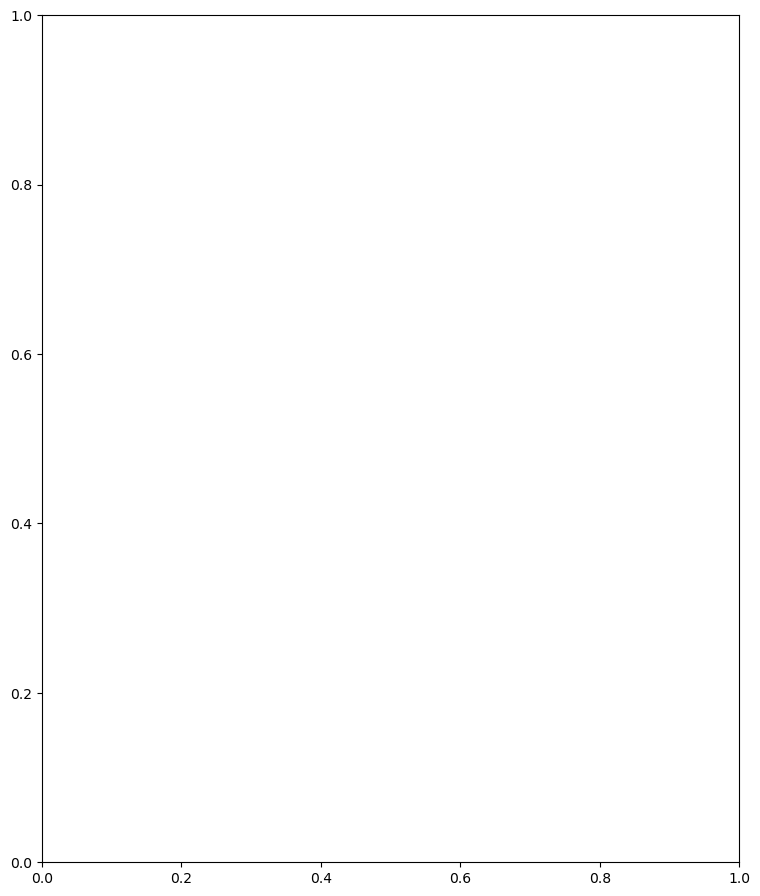

In [46]:
# ══════ MAPA 8: Porcentaje de Víctimas de Delincuencia ═══════════════════════
fig, ax = plt.subplots(figsize=(9, 11))

mapa_deli.plot(
    column       = 'Pct_victimas_2022',
    cmap         = 'OrRd',
    legend       = True,
    legend_kwds  = {'label': '% Hogares víctimas de delito', 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor    = 'white', linewidth = 0.5,
    missing_kwds = {'color': 'lightgrey', 'label': 'Sin dato'},
    ax           = ax
)

ax.set_title("Porcentaje de Víctimas de Delincuencia\nPerú — 2022 (% hogares afectados)",
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
ax.text(0.01, 0.01, "Fuente: INEI DataCrim — datacrim.inei.gob.pe",
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('mapa_delincuencia_pct.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: mapa_delincuencia_pct.png")


---
## 1️⃣3️⃣  MAPA 9 — Denuncias por Robo de Vehículos  
**Fuente:** `1. Denuncias por robo de vehiculos_1_1.xlsx`


In [47]:
# ─── PASO 23: Cargar Denuncias por Robo de Vehículos ─────────────────────────
ruta_vehiculos = r"C:\Users\LENOVO\Documents\1. Denuncias por robo de vehiculos_1_1.xlsx"

try:
    vehiculos = pd.read_excel(ruta_vehiculos)
    print("✅ Cargado")
    print("Columnas:", list(vehiculos.columns))
    display(vehiculos.head())
    
except FileNotFoundError:
    print("📋 Datos de muestra — denuncias anuales por robo de vehículos")
    vehiculos = pd.DataFrame({
        'Departamento': [
            'Huánuco','Cajamarca','Apurímac','Huancavelica','Cusco',
            'Ayacucho','Áncash','Puno','Amazonas','Piura',
            'San Martín','Junín','La Libertad','Pasco','Loreto',
            'Lambayeque','Tacna','Ucayali','Tumbes','Arequipa',
            'Moquegua','Ica','Madre de Dios','Prov. Const. Callao','Lima'
        ],
        'Denuncias_2023': [
            142, 198, 67, 43, 312,
            89, 287, 176, 54, 891,
            178, 543, 1124, 76, 134,
            672, 234, 167, 198, 1234,
            187, 543, 89, 1876, 12843
        ]
    })
    display(vehiculos.head())


✅ Cargado
Columnas: ['DENUNCIAS POR ROBO DE VEHÍCULOS, SEGÚN DEPARTAMENTO, 2017 - 2024', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21']


,"DENUNCIAS POR ROBO DE VEHÍCULOS, SEGÚN DEPARTAMENTO, 2017 - 2024",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,(Casos registrados),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Departamento,2003,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019.0,2020.0,2021.0,2022,2023.0,2024.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Total,8722,12560,10278,11226,12840,13787,15179,15881,16357,...,16501,17544,18106,19084,20159.0,13984.0,19991.0,23789,28985.0,25703.0


In [48]:
# ─── PASO 24: Merge + Mapa Denuncias Vehículos ───────────────────────────────
mapa_veh = dpto.merge(vehiculos, on='Departamento', how='left')
print(f"Missing: {mapa_veh['Denuncias_2023'].isna().sum()}")


KeyError: 'Departamento'

In [ ]:
# ══════ MAPA 9: Denuncias por Robo de Vehículos 2023 ═════════════════════════
fig, ax = plt.subplots(figsize=(9, 11))

mapa_veh.plot(
    column       = 'Denuncias_2023',
    cmap         = 'Reds',
    legend       = True,
    legend_kwds  = {'label': 'N° Denuncias (2023)', 'orientation': 'horizontal', 'pad': 0.02},
    edgecolor    = 'white', linewidth = 0.5,
    missing_kwds = {'color': 'lightgrey', 'label': 'Sin dato'},
    ax           = ax
)

ax.set_title("Denuncias por Robo de Vehículos\nPerú — 2023",
             fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
ax.text(0.01, 0.01, "Fuente: PNP — División de Estadística", 
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('mapa_robo_vehiculos.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: mapa_robo_vehiculos.png")


---
## 1️⃣4️⃣  Técnicas Adicionales de Geometría  
> De la clase del profesor — operaciones geométricas con Shapely + GeoPandas


### A. Seleccionar un Departamento Específico


In [ ]:
# ─── Seleccionar departamentos específicos para comparar ─────────────────────
dpto_idx = mapa_alfa.set_index('Departamento')

# Seleccionar regiones de interés
regiones = ['Cusco', 'Puno', 'Apurímac', 'Huancavelica']
seleccion = dpto_idx.loc[[r for r in regiones if r in dpto_idx.index]]

fig, ax = plt.subplots(figsize=(8, 8))

# Fondo gris = Perú completo
mapa_alfa.plot(ax=ax, color='#E8E8E8', edgecolor='white', linewidth=0.5)

# Resaltar la selección
seleccion.plot(
    ax           = ax,
    column       = 'Porcentaje_2024',
    cmap         = 'YlOrRd',
    edgecolor    = 'black',
    linewidth    = 1.2,
    legend       = True
)

ax.set_title("Departamentos seleccionados\n(Región Sur del Perú)", 
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


### B. Operaciones Espaciales: Touches y Distancias

In [ ]:
# ─── Calcular centroides para operar geométricamente ────────────────────────
dpto_geo_calc = mapa_alfa.set_index('Departamento').copy()
dpto_geo_calc['centroid'] = (
    dpto_geo_calc['geometry']
    .to_crs('EPSG:24891')
    .centroid
    .to_crs('EPSG:4326')
)

# ¿Cusco y Puno comparten límite?
cusco = dpto_geo_calc.loc['Cusco', 'geometry'] if 'Cusco' in dpto_geo_calc.index else None
puno  = dpto_geo_calc.loc['Puno',  'geometry'] if 'Puno'  in dpto_geo_calc.index else None

if cusco and puno:
    print(f"¿Cusco toca (limita con) Puno? → {cusco.touches(puno)}")
    print(f"Distancia en grados entre centroides: {dpto_geo_calc.loc['Cusco','centroid'].distance(dpto_geo_calc.loc['Puno','centroid']):.4f}°")


In [ ]:
# ─── Distancia desde Lima a todos los departamentos ──────────────────────────
if 'Lima' in dpto_geo_calc.index:
    lima_centroid = dpto_geo_calc.loc['Lima', 'centroid']
    
    # Calcular en metros (UTM)
    dpto_utm = mapa_alfa.copy().set_index('Departamento')
    dpto_utm['centroid_utm'] = dpto_utm['geometry'].to_crs('EPSG:24891').centroid
    lima_utm = dpto_utm.loc['Lima', 'centroid_utm']
    
    dpto_utm['dist_km'] = dpto_utm['centroid_utm'].apply(
        lambda pt: lima_utm.distance(pt) / 1000 if pt else None
    )
    
    print("Distancia desde Lima (km) — por centroide de departamento:")
    resultado = dpto_utm['dist_km'].sort_values(ascending=False).reset_index()
    resultado.columns = ['Departamento', 'Distancia_km']
    display(resultado.head(10))


In [ ]:
# ─── Gráfico de barras: distancia desde Lima ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

resultado.sort_values('Distancia_km', ascending=True).plot.barh(
    x         = 'Departamento',
    y         = 'Distancia_km',
    ax        = ax,
    color     = '#1C7293',
    edgecolor = 'white',
    legend    = False
)

ax.set_title("Distancia desde Lima al Centroide de cada Departamento (km)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Kilómetros")
plt.tight_layout()
plt.show()


### C. Agregar (Dissolve) — del distrito al departamento

In [ ]:
# ─── Dissolve: agregar polígonos por una variable ────────────────────────────
# Ejemplo conceptual: si tuviéramos shapefile distrital, 
# podemos agregar a nivel departamental con dissolve

# Con nuestro mapa departamental, mostramos la operación:
# (Simulación: si tuviéramos columna Macroregion)

macroregiones = {
    'Lima': 'Centro', 'Áncash': 'Centro', 'Junín': 'Centro', 'Pasco': 'Centro',
    'Huánuco': 'Centro', 'Ica': 'Centro', 'Huancavelica': 'Centro',
    'Arequipa': 'Sur', 'Cusco': 'Sur', 'Puno': 'Sur', 'Moquegua': 'Sur',
    'Tacna': 'Sur', 'Apurímac': 'Sur', 'Ayacucho': 'Sur',
    'Piura': 'Norte', 'Lambayeque': 'Norte', 'La Libertad': 'Norte',
    'Cajamarca': 'Norte', 'Áncash': 'Norte', 'Amazonas': 'Norte',
    'Tumbes': 'Norte',
    'Loreto': 'Oriente', 'San Martín': 'Oriente', 'Ucayali': 'Oriente',
    'Madre de Dios': 'Oriente',
    'Prov. Const. Callao': 'Centro'
}

mapa_alfa['Macroregion'] = mapa_alfa['Departamento'].map(macroregiones)

# Dissolve: unir polígonos por macroregión
macro_shp = mapa_alfa.dissolve(by='Macroregion', aggfunc='mean')[['Porcentaje_2024','geometry']]

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

mapa_alfa.plot(ax=axes[0], column='Macroregion', cmap='Set2',
               edgecolor='white', linewidth=0.5, legend=True,
               legend_kwds={'loc': 'lower left', 'fontsize': 8})
axes[0].set_title("División por Macroregiones\n(nivel departamental)", fontsize=12, fontweight='bold')
axes[0].axis('off')

macro_shp.plot(ax=axes[1], column='Porcentaje_2024', cmap='YlOrRd',
               edgecolor='black', linewidth=1.2, legend=True)
axes[1].set_title("Analfabetismo promedio\npor Macroregión (dissolve)", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Operación Dissolve — Agregar polígonos por categoría", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ dissolve() — colapsa N polígonos en 1 por categoría")


---
## 📚 Referencias y Fuentes de Datos

### Geometría del Perú
- **GeoBoundaries** (College of William & Mary): https://www.geoboundaries.org/api/current/gbOpen/PER/ADM1/
- **HDX — OCHA** (ONU): https://data.humdata.org/dataset/cod-ab-per
- **IDE INEI** (oficial Perú): https://ide.inei.gob.pe/
- **GeoGPS Perú**: https://www.geogpsperu.com/2019/05/limite-distrital-actualizado-inei.html

### Datos Económicos — Perú
- **INEI DataCrim** (delincuencia): https://datacrim.inei.gob.pe/
- **INEI Microdatos** (ENAHO, ENDES): https://iinei.inei.gob.pe/microdatos/
- **INEI Analfabetismo**: https://www.inei.gob.pe/estadisticas/indice-tematico/education/
- **DEVIDA / UNODC** (siembra de coca): https://www.devida.gob.pe/
- **MEF — Consulta Amigable** (presupuesto carreteras): https://apps5.mineco.gob.pe/transparencia/

### Librerías Python
- **GeoPandas**: https://geopandas.org/en/stable/
- **Shapely**: https://shapely.readthedocs.io/
- **Matplotlib**: https://matplotlib.org/stable/gallery/index.html

### Bibliografía recomendada
- Rey, Arribas-Bel & Wolf (2023). *Geographic Data Science with Python*: https://geographicdata.science/book/
- Lovelace, Nowosad & Muenchow (2019). *Geocomputation with R*: https://r.geocompx.org/
